In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import missingno as msno
import os
import re

# *Importing The Dataset*:

In [ ]:
import kagglehub

path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce


In [ ]:
tables = os.listdir(path)
tables

['olist_customers_dataset.csv',
 'olist_sellers_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_products_dataset.csv',
 'olist_geolocation_dataset.csv',
 'product_category_name_translation.csv',
 'olist_orders_dataset.csv',
 'olist_order_payments_dataset.csv']

# *Creating **dataset** and **metadata dicts** of tables:*

The ***dataset*** and ***metadata_catalog*** keeps all tables as key-values where **key** is a table name and **value** is DataFrame and metadata of tables respectively.

In [ ]:
dataset = {}
metadata_catalog = {}

for table in tables:
  table_name = table.strip().split(sep=".")[0]
  table_name = re.sub("olist_|_dataset", "", table_name)
  file_path = path + "/" + table

  df = pd.read_csv(file_path)
  dataset[table_name] = df

  metadata_catalog[table_name] = pd.DataFrame({
      "Columns": df.columns,
      "Non-Null Count": df.notnull().sum().values,
      "Null Count": df.isnull().sum().values,
      "Null %": (df.isnull().mean() * 100).round(2),
      "Dtype": df.dtypes.astype(str),
      "Unique Values": df.nunique().values,
      "Example Value": [df[df[column].notnull()][column].iloc[0] for column in df.columns]
  }).reset_index(drop=True)

---

# ***General Summary** of all tables of the dataset:*

In [ ]:
summary_table = []

for table_name, df in dataset.items():
  total_count = len(df)
  missing_count = df.isnull().any(axis=1).sum()
  missing_ratio = f"{(missing_count / total_count + 1e-5):.2%}"
  top_null_rows = None

  if missing_count != 0:
    nulls_by_rows = dataset[table_name].isnull().sum().sort_values(ascending=False)
    top_null_rows = nulls_by_rows[nulls_by_rows > 0].iloc[:3].index.to_list()
    top_null_rows = ", ".join(top_null_rows)
  else:
    missing_count = "0 🎉️"
    missing_ratio = "0%"

  summary_table.append({
      "Table Name": table_name,
      "Total Rows": total_count,
      "Rows With Missing Values": missing_count,
      "Missing %": missing_ratio,
      "Top Rows With Missing Values": top_null_rows
  })

summary_df = pd.DataFrame(summary_table)
summary_df

,Table Name,Total Rows,Rows With Missing Values,Missing %,Top Rows With Missing Values
0,customers,99441,0 🎉️,0%,None
1,sellers,3095,0 🎉️,0%,None
2,order_reviews,99224,89385,90.09%,"review_comment_title, review_comment_message"
3,order_items,112650,0 🎉️,0%,None
4,products,32951,611,1.86%,"product_category_name, product_description_len..."
5,geolocation,1000163,0 🎉️,0%,None
6,product_category_name_translation,71,0 🎉️,0%,None
7,orders,99441,2980,3.00%,"order_delivered_customer_date, order_delivered..."
8,order_payments,103886,0 🎉️,0%,None


---

# *Exploring and Visualizing tables with missing values to find any **anomalies** or **relationships*** :

In [ ]:
sus_tables = ["order_reviews", "products", "orders"]
sus_tables_rel = {}

## Exploring the table **<mark>order_reviews</mark>:**

In [ ]:
metadata_catalog[sus_tables[0]]

,Columns,Non-Null Count,Null Count,Null %,Dtype,Unique Values,Example Value
0,review_id,99224,0,0.00,object,98410,7bc2406110b926393aa56f80a40eba40
1,order_id,99224,0,0.00,object,98673,73fc7af87114b39712e6da79b0a377eb
2,review_score,99224,0,0.00,int64,5,4
3,review_comment_title,11568,87656,88.34,object,4527,recomendo
4,review_comment_message,40977,58247,58.70,object,36159,Recebi bem antes do prazo estipulado.
5,review_creation_date,99224,0,0.00,object,636,2018-01-18 00:00:00
6,review_answer_timestamp,99224,0,0.00,object,98248,2018-01-18 21:46:59


In [ ]:
rev = dataset[sus_tables[0]][[
    "review_score",
    "review_creation_date",
    "review_comment_title",
    "review_comment_message"
]].copy()

rev["review_creation_date"] = pd.to_datetime(rev["review_creation_date"])

for col in ["review_comment_title", "review_comment_message"]:
    rev[col] = rev[col].isnull().replace({True: "Null", False: "Not Null"})

Plotting the main two columns with **most null values** against the ***creation dates and scores given***.

**Hypothesis**: null rate in ***review_comment_title and review_comment_message*** is not random, but varies with ***review_score and review_creation_date***:

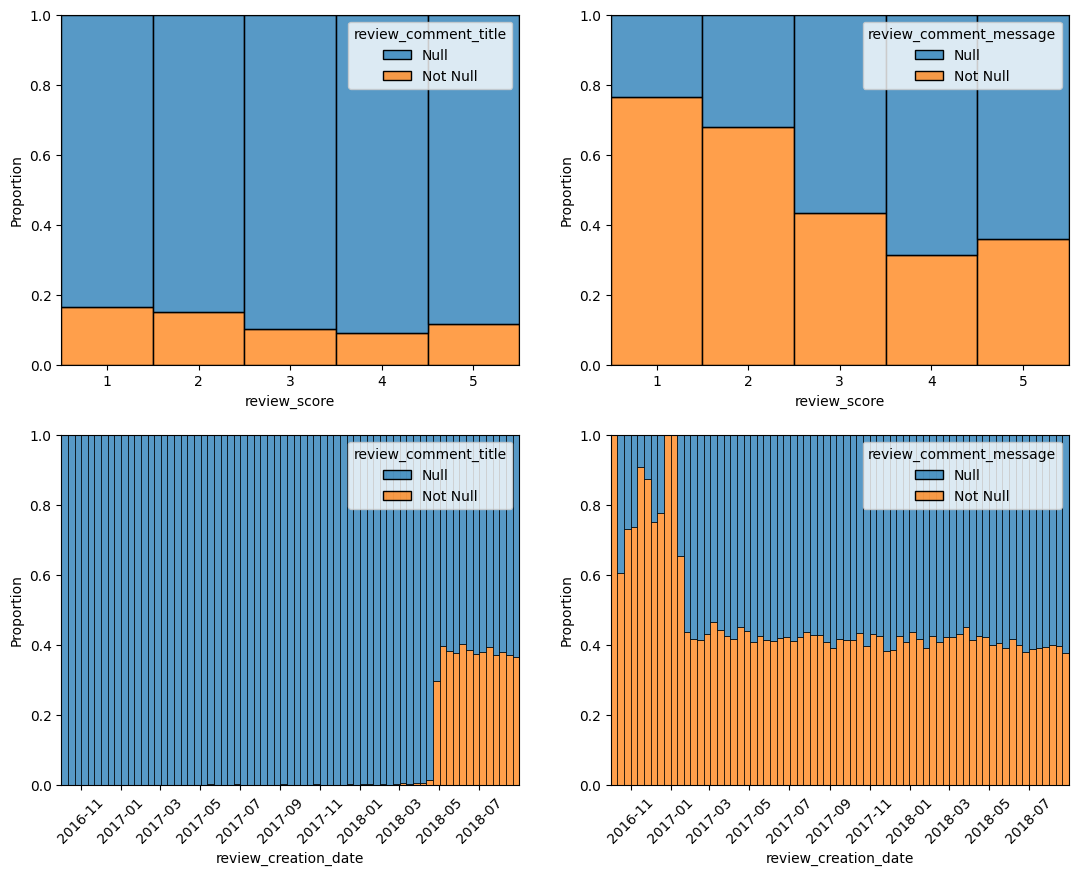

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.histplot(rev[["review_score", "review_comment_title"]],
             x="review_score",
             hue="review_comment_title",
             ax=axes[0, 0],
             multiple="fill",
             discrete=True
             )

sns.histplot(rev[["review_score", "review_comment_message"]],
             x="review_score",
             hue="review_comment_message",
             ax=axes[0, 1],
             multiple="fill",
             discrete=True
             )

sns.histplot(rev[["review_creation_date", "review_comment_title"]],
             x="review_creation_date",
             hue="review_comment_title",
             ax=axes[1, 0],
             multiple="fill"
             )

sns.histplot(rev[["review_creation_date", "review_comment_message"]],
             x="review_creation_date",
             hue="review_comment_message",
             ax=axes[1, 1],
             multiple="fill"
             )

axes[1,0].tick_params(axis="x", rotation=45)
axes[1,1].tick_params(axis="x", rotation=45)

for ax in axes.flat:
    ax.set_ylabel("Proportion")

plt.show()

**Graph Interpretation:** Each bar = 100% of reviews in that score/month. Orange = comment present,
Blue = comment missing. Compare bar *shares*, not heights — height is
fixed at 1.0 by design (multiple="fill").

### Conclusions:

**review_comment_title**: Fail to reject H0 (not random).
Dominated by time: ~100% null until Apr 2018, then ~40%, flat after.
Score has minimal added effect. >> structural break (likely form change).

**review_comment_message**: Fail to reject H0 (not random).
Stable over time (noisy early months, small n). Null rate falls
~77% (score 1) >> ~35-40% (score 4-5). >> behavioral MAR, tied to score.

### Decision:

No row or column dropping. We crate two cols

---

## Exploring the next table **<mark>products</mark>:**

In [ ]:
metadata_catalog[sus_tables[1]]

,Columns,Non-Null Count,Null Count,Null %,Dtype,Unique Values,Example Value
0,product_id,32951,0,0.00,object,32951,1e9e8ef04dbcff4541ed26657ea517e5
1,product_category_name,32341,610,1.85,object,73,perfumaria
2,product_name_lenght,32341,610,1.85,float64,66,40.0
3,product_description_lenght,32341,610,1.85,float64,2960,287.0
4,product_photos_qty,32341,610,1.85,float64,19,1.0
5,product_weight_g,32949,2,0.01,float64,2204,225.0
6,product_length_cm,32949,2,0.01,float64,99,16.0
7,product_height_cm,32949,2,0.01,float64,102,10.0
8,product_width_cm,32949,2,0.01,float64,95,14.0


In [ ]:
dataset[sus_tables[1]].isnull().sum(axis=1).value_counts()

,count
0,32340
4,610
8,1


In [ ]:
product_order_df = pd.merge(
    dataset[sus_tables[1]],
    dataset["order_items"],
    on="product_id",
    how="inner"
)

product_order_df.isnull()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_id,order_item_id,seller_id,shipping_limit_date,price,freight_value
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
112646,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
112647,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
112648,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
metadata_catalog['order_items']

,Columns,Non-Null Count,Null Count,Null %,Dtype,Unique Values,Example Value
0,order_id,112650,0,0.0,object,98666,00010242fe8c5a6d1ba2dd792cb16214
1,order_item_id,112650,0,0.0,int64,21,1
2,product_id,112650,0,0.0,object,32951,4244733e06e7ecb4970a6e2683c13e61
3,seller_id,112650,0,0.0,object,3095,48436dade18ac8b2bce089ec2a041202
4,shipping_limit_date,112650,0,0.0,object,93318,2017-09-19 09:45:35
5,price,112650,0,0.0,float64,5968,58.9
6,freight_value,112650,0,0.0,float64,6999,13.29


---

## Exploring the last table **<mark>orders</mark>:**

In [ ]:
metadata_catalog[sus_tables[2]]

,Columns,Non-Null Count,Null Count,Null %,Dtype,Unique Values,Example Value
0,order_id,99441,0,0.00,object,99441,e481f51cbdc54678b7cc49136f2d6af7
1,customer_id,99441,0,0.00,object,99441,9ef432eb6251297304e76186b10a928d
2,order_status,99441,0,0.00,object,8,delivered
3,order_purchase_timestamp,99441,0,0.00,object,98875,2017-10-02 10:56:33
4,order_approved_at,99281,160,0.16,object,90733,2017-10-02 11:07:15
5,order_delivered_carrier_date,97658,1783,1.79,object,81018,2017-10-04 19:55:00
6,order_delivered_customer_date,96476,2965,2.98,object,95664,2017-10-10 21:25:13
7,order_estimated_delivery_date,99441,0,0.00,object,459,2017-10-18 00:00:00


In [ ]:
sus_tables_rel[sus_tables[2]] = dataset[sus_tables[2]].groupby("order_status")[[
    "order_approved_at",
    "order_delivered_customer_date",
    "order_delivered_carrier_date"
    ]].apply(lambda x: x.isnull().mean().round(2))

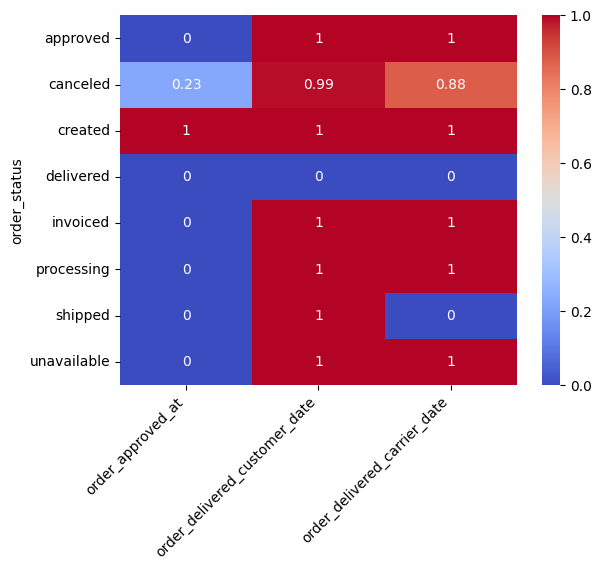

In [ ]:
sns.heatmap(sus_tables_rel[sus_tables[2]], annot=True, vmin=0, vmax=1, cmap="coolwarm")
plt.xticks(rotation=45, ha="right")
plt.show()

In [ ]:
sus_tables_rel[sus_tables[2]]

,order_approved_at,order_delivered_customer_date,order_delivered_carrier_date
order_status,,,
approved,0.00,1.00,1.00
canceled,0.23,0.99,0.88
created,1.00,1.00,1.00
delivered,0.00,0.00,0.00
invoiced,0.00,1.00,1.00
processing,0.00,1.00,1.00
shipped,0.00,1.00,0.00
unavailable,0.00,1.00,1.00
